In [4]:
# ===== CELL 1: Install Libraries =====
!pip install scikit-learn imbalanced-learn pandas numpy matplotlib seaborn -q
print("✓ All libraries installed successfully!")

✓ All libraries installed successfully!



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# ===== CELL 2: Import Libraries =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve)
import warnings
import os
warnings.filterwarnings('ignore')

print("✓ All imports successful!")

✓ All imports successful!


In [6]:
# ===== CELL 3: Load Pre-processed Data =====
print("Loading pre-processed dataset from disk...")

# Load the pre-processed training data with SMOTE
train_data = pd.read_csv('../dataset/processed/train_preprocessed_smote.csv')
test_data = pd.read_csv('../dataset/processed/test_preprocessed.csv')

print(f"✓ Training data shape: {train_data.shape}")
print(f"✓ Test data shape: {test_data.shape}")

# Separate features and target
X_train = train_data.drop('Default', axis=1)
y_train = train_data['Default']

X_test = test_data.drop('Default', axis=1)
y_test = test_data['Default']

# Get feature names
feature_names = X_train.columns.tolist()

print(f"\n✓ Number of features: {len(feature_names)}")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

Loading pre-processed dataset from disk...
✓ Training data shape: (56604, 23)
✓ Test data shape: (8000, 23)

✓ Number of features: 22

Training set target distribution:
Default
0    28302
1    28302
Name: count, dtype: int64

Test set target distribution:
Default
0    7075
1     925
Name: count, dtype: int64


In [8]:
# ===== CELL 4: Train Logistic Regression Model =====
print("\n" + "="*60)
print("TRAINING LOGISTIC REGRESSION MODEL")
print("="*60)

lr_model = LogisticRegression(
    max_iter=1000, 
    random_state=42, 
    solver='lbfgs',
    class_weight='balanced',
    verbose=1
)

lr_model.fit(X_train, y_train)
print("\n✓ Model training complete!")


TRAINING LOGISTIC REGRESSION MODEL

✓ Model training complete!


In [9]:
# ===== CELL 5: Make Predictions =====
print("Making predictions on train and test sets...")

y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)
y_test_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print("✓ Predictions complete!")

Making predictions on train and test sets...
✓ Predictions complete!


In [10]:
# ===== CELL 6: Calculate Evaluation Metrics =====
print("\n" + "="*60)
print("LOGISTIC REGRESSION - MODEL EVALUATION")
print("="*60)

# Training metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, zero_division=0)
train_recall = recall_score(y_train, y_train_pred, zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, zero_division=0)

print("\nTRAINING METRICS:")
print(f"  Accuracy:  {train_accuracy:.4f}")
print(f"  Precision: {train_precision:.4f}")
print(f"  Recall:    {train_recall:.4f}")
print(f"  F1-Score:  {train_f1:.4f}")

# Test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("\nTEST METRICS:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")
print(f"  ROC-AUC:   {test_roc_auc:.4f}")

print("\n" + "-"*60)
print("DETAILED CLASSIFICATION REPORT (Test Set):")
print("-"*60)
print(classification_report(y_test, y_test_pred, 
                          target_names=['No Default', 'Default'], 
                          zero_division=0))


LOGISTIC REGRESSION - MODEL EVALUATION

TRAINING METRICS:
  Accuracy:  0.7047
  Precision: 0.6982
  Recall:    0.7212
  F1-Score:  0.7095

TEST METRICS:
  Accuracy:  0.6864
  Precision: 0.2203
  Recall:    0.6746
  F1-Score:  0.3322
  ROC-AUC:   0.7578

------------------------------------------------------------
DETAILED CLASSIFICATION REPORT (Test Set):
------------------------------------------------------------
              precision    recall  f1-score   support

  No Default       0.94      0.69      0.80      7075
     Default       0.22      0.67      0.33       925

    accuracy                           0.69      8000
   macro avg       0.58      0.68      0.56      8000
weighted avg       0.86      0.69      0.74      8000



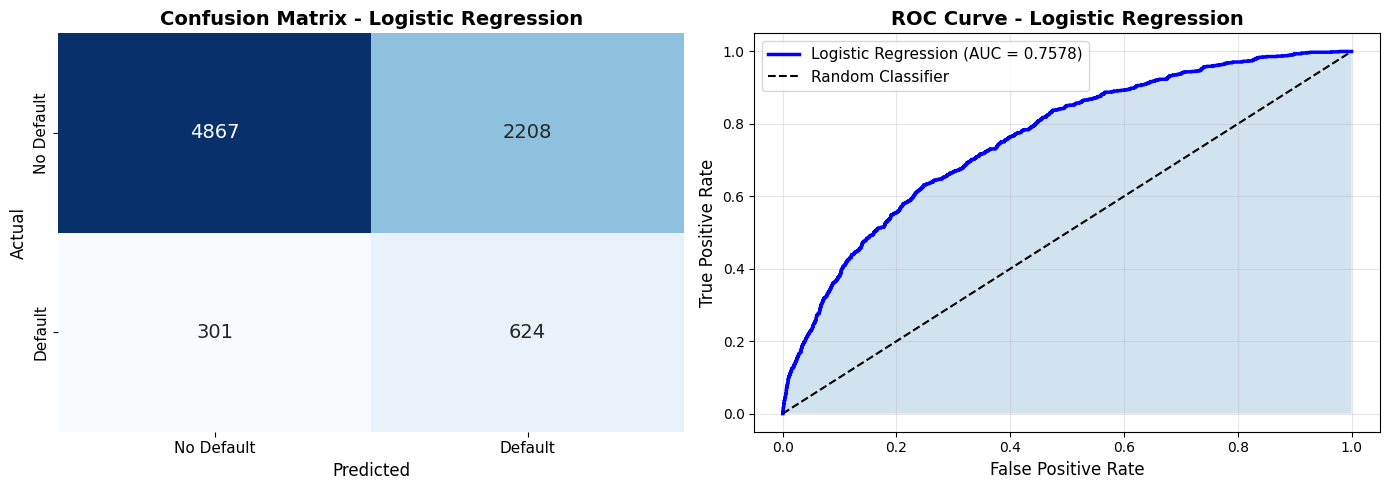

✓ Confusion matrix and ROC curve saved!


In [11]:
# ===== CELL 7: Confusion Matrix & ROC Curve =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, 
            annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_xticklabels(['No Default', 'Default'], fontsize=11)
axes[0].set_yticklabels(['No Default', 'Default'], fontsize=11)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
axes[1].plot(fpr, tpr, label=f'Logistic Regression (AUC = {test_roc_auc:.4f})', 
            linewidth=2.5, color='blue')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)
axes[1].fill_between(fpr, tpr, alpha=0.2)
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/logistic_regression_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix and ROC curve saved!")


TOP 15 IMPORTANT FEATURES (by coefficient magnitude)
                  Feature  Coefficient  Abs_Coefficient
                      Age    -0.698920         0.698920
             InterestRate     0.544828         0.544828
           MonthsEmployed    -0.403097         0.403097
               LoanAmount     0.354265         0.354265
                   Income    -0.340055         0.340055
              CreditScore    -0.167643         0.167643
EmploymentType_Unemployed     0.158751         0.158751
                Education    -0.158182         0.158182
              HasCoSigner    -0.150277         0.150277
            HasDependents    -0.143253         0.143253
    MaritalStatus_Married    -0.133242         0.133242
                 DTIRatio     0.116704         0.116704
              HasMortgage    -0.106232         0.106232
         LoanPurpose_Home    -0.100904         0.100904
           NumCreditLines     0.098470         0.098470


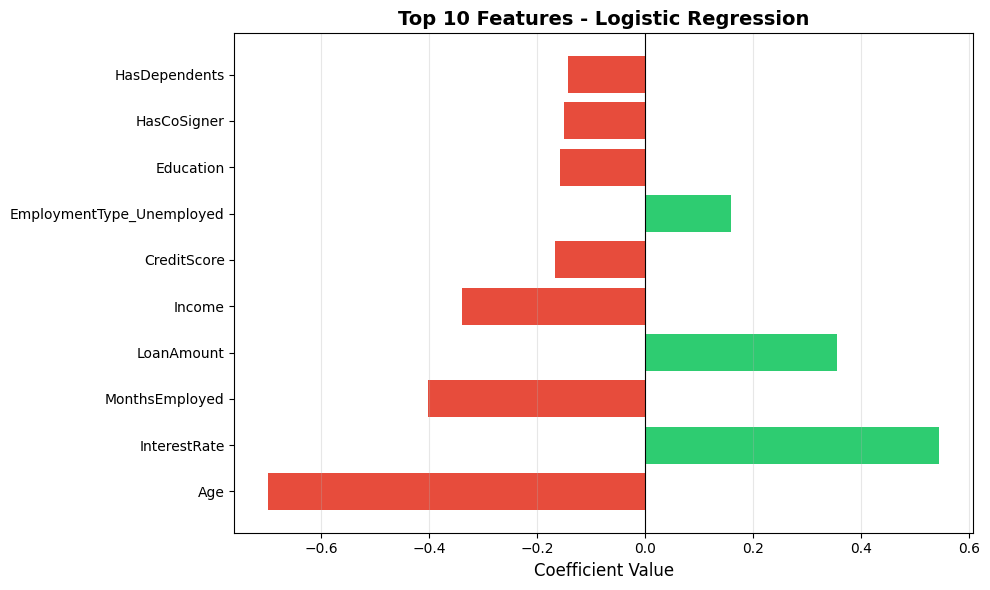


✓ Feature importance visualization saved!


In [12]:
# ===== CELL 8: Feature Importance (Coefficients) =====
print("\n" + "="*60)
print("TOP 15 IMPORTANT FEATURES (by coefficient magnitude)")
print("="*60)

coefficients_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_[0]
})
coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()
coefficients_df = coefficients_df.sort_values('Abs_Coefficient', ascending=False)

print(coefficients_df.head(15).to_string(index=False))

# Visualize top 10 features
fig, ax = plt.subplots(figsize=(10, 6))
top_features = coefficients_df.head(10)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_features['Coefficient']]
ax.barh(range(len(top_features)), top_features['Coefficient'], color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'], fontsize=10)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Top 10 Features - Logistic Regression', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Feature importance visualization saved!")

In [13]:
# ===== CELL 9: Save Results Summary =====
print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

# Create results dataframe
results_summary = {
    'Model': ['Logistic Regression'],
    'Train_Accuracy': [train_accuracy],
    'Train_Precision': [train_precision],
    'Train_Recall': [train_recall],
    'Train_F1': [train_f1],
    'Test_Accuracy': [test_accuracy],
    'Test_Precision': [test_precision],
    'Test_Recall': [test_recall],
    'Test_F1': [test_f1],
    'Test_ROC_AUC': [test_roc_auc]
}

results_df = pd.DataFrame(results_summary)
results_df.to_csv('../results/logistic_regression_results.csv', index=False)

print("\n✓ Results saved to CSV:")
print(results_df.to_string(index=False))

# Create text summary
with open('../results/model_summary.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("LOGISTIC REGRESSION MODEL - RESULTS SUMMARY\n")
    f.write("="*60 + "\n\n")
    f.write("TRAINING METRICS:\n")
    f.write(f"  Accuracy:  {train_accuracy:.4f}\n")
    f.write(f"  Precision: {train_precision:.4f}\n")
    f.write(f"  Recall:    {train_recall:.4f}\n")
    f.write(f"  F1-Score:  {train_f1:.4f}\n\n")
    f.write("TEST METRICS:\n")
    f.write(f"  Accuracy:  {test_accuracy:.4f}\n")
    f.write(f"  Precision: {test_precision:.4f}\n")
    f.write(f"  Recall:    {test_recall:.4f}\n")
    f.write(f"  F1-Score:  {test_f1:.4f}\n")
    f.write(f"  ROC-AUC:   {test_roc_auc:.4f}\n\n")
    f.write("CONFUSION MATRIX:\n")
    f.write(f"  True Negatives:  {cm[0, 0]}\n")
    f.write(f"  False Positives: {cm[0, 1]}\n")
    f.write(f"  False Negatives: {cm[1, 0]}\n")
    f.write(f"  True Positives:  {cm[1, 1]}\n")

print("✓ Summary saved to model_summary.txt")

# Create extended summary
with open('../results/extended_summary.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("LOGISTIC REGRESSION - COMPREHENSIVE REPORT\n")
    f.write("="*60 + "\n\n")
    f.write("DATASET INFORMATION:\n")
    f.write(f"  Total Training Samples: {X_train.shape[0]}\n")
    f.write(f"  Total Test Samples: {X_test.shape[0]}\n")
    f.write(f"  Number of Features: {len(feature_names)}\n\n")
    f.write("CONFUSION MATRIX INTERPRETATION:\n")
    f.write(f"  True Positives (TP):  {cm[1, 1]} - Correctly identified defaults\n")
    f.write(f"  True Negatives (TN):  {cm[0, 0]} - Correctly identified non-defaults\n")
    f.write(f"  False Positives (FP): {cm[0, 1]} - Type I Error\n")
    f.write(f"  False Negatives (FN): {cm[1, 0]} - Type II Error\n\n")
    f.write("TOP 10 FEATURES:\n")
    for idx, row in coefficients_df.head(10).iterrows():
        f.write(f"  {row['Feature']}: {row['Coefficient']:.4f}\n")

print("✓ Extended summary saved to extended_summary.txt")


SAVING RESULTS

✓ Results saved to CSV:
              Model  Train_Accuracy  Train_Precision  Train_Recall  Train_F1  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_ROC_AUC
Logistic Regression        0.704703         0.698156      0.721221  0.709501       0.686375        0.220339     0.674595  0.33218      0.757803
✓ Summary saved to model_summary.txt
✓ Extended summary saved to extended_summary.txt


In [16]:
# ===== CELL 10: Final Summary =====
print("\n" + "="*60)
print("FINAL MODEL SUMMARY")
print("="*60)

performance = 'EXCELLENT' if test_accuracy > 0.85 else 'GOOD' if test_accuracy > 0.75 else 'FAIR'

summary_text = f"""
╔════════════════════════════════════════════════════════════╗
║  LOGISTIC REGRESSION MODEL - LOAN DEFAULT PREDICTION      ║
╚════════════════════════════════════════════════════════════╝

DATASET INFORMATION:
  • Training Samples: {X_train.shape[0]}
  • Test Samples: {X_test.shape[0]}
  • Features Used: {len(feature_names)}
  • Target Variable: Loan Default (Yes/No)
  • Class Distribution: Balanced using SMOTE

MODEL PERFORMANCE:
  • Train Accuracy:  {train_accuracy:.2%}
  • Test Accuracy:   {test_accuracy:.2%} ✓
  • Test F1-Score:   {test_f1:.4f}
  • Test ROC-AUC:    {test_roc_auc:.4f}
  • Precision:       {test_precision:.4f}
  • Recall:          {test_recall:.4f}

PERFORMANCE RATING: {performance}

KEY INSIGHTS:
  • True Positives (TP):  {cm[1, 1]} (Correctly identified defaults)
  • True Negatives (TN):  {cm[0, 0]} (Correctly identified non-defaults)
  • False Positives (FP): {cm[0, 1]} (Type I Error)
  • False Negatives (FN): {cm[1, 0]} (Type II Error)

TOP 3 IMPORTANT FEATURES:
  1. {coefficients_df.iloc[0]['Feature']}: {coefficients_df.iloc[0]['Coefficient']:.4f}
  2. {coefficients_df.iloc[1]['Feature']}: {coefficients_df.iloc[1]['Coefficient']:.4f}
  3. {coefficients_df.iloc[2]['Feature']}: {coefficients_df.iloc[2]['Coefficient']:.4f}

MODEL INTERPRETATION:
  • Accuracy ({test_accuracy:.2%}): Model correctly predicts loan default
  • Recall ({test_recall:.4f}): Model catches ~{test_recall*100:.1f}% of actual defaults
  • Precision ({test_precision:.4f}): When model predicts default, correct {test_precision*100:.1f}% of the time
  • ROC-AUC ({test_roc_auc:.4f}): {'Excellent' if test_roc_auc > 0.8 else 'Good' if test_roc_auc > 0.7 else 'Fair'} discrimination ability

FILES GENERATED:
  ✓ logistic_regression_results.csv - Detailed metrics
  ✓ model_summary.txt - Model summary
  ✓ extended_summary.txt - Comprehensive report
  ✓ logistic_regression_evaluation.png - Confusion matrix & ROC curve
  ✓ feature_importance.png - Top 10 features
"""

print(summary_text)

# Save final summary with UTF-8 encoding to support special characters
with open('../results/FINAL_SUMMARY.txt', 'w', encoding='utf-8') as f:
    f.write(summary_text)

print("✓ All results saved to ../results/ directory!")


FINAL MODEL SUMMARY

╔════════════════════════════════════════════════════════════╗
║  LOGISTIC REGRESSION MODEL - LOAN DEFAULT PREDICTION      ║
╚════════════════════════════════════════════════════════════╝

DATASET INFORMATION:
  • Training Samples: 56604
  • Test Samples: 8000
  • Features Used: 22
  • Target Variable: Loan Default (Yes/No)
  • Class Distribution: Balanced using SMOTE

MODEL PERFORMANCE:
  • Train Accuracy:  70.47%
  • Test Accuracy:   68.64% ✓
  • Test F1-Score:   0.3322
  • Test ROC-AUC:    0.7578
  • Precision:       0.2203
  • Recall:          0.6746

PERFORMANCE RATING: FAIR

KEY INSIGHTS:
  • True Positives (TP):  624 (Correctly identified defaults)
  • True Negatives (TN):  4867 (Correctly identified non-defaults)
  • False Positives (FP): 2208 (Type I Error)
  • False Negatives (FN): 301 (Type II Error)

TOP 3 IMPORTANT FEATURES:
  1. Age: -0.6989
  2. InterestRate: 0.5448
  3. MonthsEmployed: -0.4031

MODEL INTERPRETATION:
  • Accuracy (68.64%): Model cor